In [ ]:
import random
import time
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Bài 1:

## **1. Bài toán khớp xâu:** Tìm các vị trí xuất hiện của xâu mẫu P trong văn bản T cho trước.

In [ ]:
def backtracking_string_matching(T, P):
    positions = []  # Danh sách lưu các vị trí khớp

    def try_match(start, j):
        """
        start: Vị trí bắt đầu trong T để thử khớp P
        j: Chỉ số hiện tại trong P (đang khớp P[j] với T[start + j])
        """
        # Nếu đã khớp toàn bộ P
        if j == len(P):
            positions.append(start)
            return

        # Nếu vượt quá độ dài của T, dừng lại
        if start + j >= len(T):
            return

        # Nếu ký tự tại vị trí hiện tại khớp
        if T[start + j] == P[j]:
            try_match(start, j + 1)  # Tiếp tục khớp ký tự tiếp theo của P

    # Thử khớp P tại từng vị trí bắt đầu trong T
    for start in range(len(T) - len(P) + 1):
        try_match(start, 0)

    return positions

In [ ]:
def test_string_matching():
    # Test case 1
    T1 = "AABAACAADA"
    P1 = "AA"
    print(f"T = {T1}, P = {P1}")
    print("Vị trí khớp:", backtracking_string_matching(T1, P1))  # Kết quả: [0, 3]

    # Test case 2
    T2 = "ABABABAB"
    P2 = "ABA"
    print(f"T = {T2}, P = {P2}")
    print("Vị trí khớp:", backtracking_string_matching(T2, P2))  # Kết quả: [0, 2, 4]

    # Test case 3
    T3 = "HELLO"
    P3 = "XYZ"
    print(f"T = {T3}, P = {P3}")
    print("Vị trí khớp:", backtracking_string_matching(T3, P3))  # Kết quả: []

if __name__ == "__main__":
    test_string_matching()

T = AABAACAADA, P = AA
Vị trí khớp: [0, 3, 6]
T = ABABABAB, P = ABA
Vị trí khớp: [0, 2, 4]
T = HELLO, P = XYZ
Vị trí khớp: []


## **2. Bài toán dãy nhị phân:** Liệt kê các dãy nhị phân có độ dài n.

In [ ]:
def backtracking_binary_sequences(n):
    result = []
    def generate(seq):
        if len(seq) == n:
            result.append(seq)
            return
        generate(seq + '0')
        generate(seq + '1')
    generate('')
    return result

In [ ]:
def measure_time(func, n):
    start = time.time()
    func(n)
    end = time.time()
    return end - start

# Chạy với các kích thước đầu vào
sizes = [5, 10, 15, 20]  # giới hạn đến 20 vì lớn hơn sẽ gây bùng nổ tổ hợp
results = []
for size in sizes:
    results.append({
        'Input Size (n)': size,
        'Backtracking Time': measure_time(backtracking_binary_sequences, size)
    })
df_binary_results = pd.DataFrame(results)
output_binary_file = '/content/binary_sequence_times.xlsx'
df_binary_results.to_excel(output_binary_file, index=False)

output_binary_file

'/content/binary_sequence_times.xlsx'

## **3. Đường đi trong mê cung:** Tìm đường đi từ A đến B trong mê cung.

In [ ]:
def find_path_in_maze(maze, A, B):
  # # Input:
  #   // - maze: Ma trận 2D biểu diễn mê cung (0: ô trống, 1: tường)
  #   // - A: Tọa độ điểm bắt đầu (x_A, y_A)
  #   // - B: Tọa độ điểm kết thúc (x_B, y_B)
  rows = len(maze)
  cols = len(maze[0])
  visited = [[False for _ in range(cols)] for _ in range(rows)]
  path = []
  found = False
  def find_path(x, y):
    nonlocal found
    # Nếu đã tìm thấy điểm đích
    if x == B[0] and y == B[1]:
      found = True
      return
    # Thử lên, xuống, trái, phải
    for direction in ["up", "down", "right", "left"]:
      if direction == "up":
        new_x = x - 1
        new_y = y
      elif direction == "down":
        new_x = x + 1
        new_y = y
      elif direction == "right":
        new_x = x
        new_y = y + 1
      else:
        new_x = x
        new_y = y - 1
      # Kiểm tra xem ô mới có an toàn không
      if 0 <= new_x < rows and 0 <= new_y < cols and maze[new_x][new_y] == 0 and not visited[new_x][new_y]:
        visited[new_x][new_y] = True
        path.append((new_x, new_y))
        find_path(new_x, new_y)
        if found:
          return
        path.pop()
        visited[new_x][new_y] = False

  visited[A[0]][A[1]] = True
  path.append((A[0], A[1]))
  find_path(A[0], A[1])
  if found:
    return path
  else:
    return "Không tìm thấy đường đi"

In [ ]:
def measure_time(func, maze, start, end):
    start_time = time.time()
    func(maze, start, end)
    return time.time() - start_time

# Kích thước mê cung (cỡ nhỏ và trung bình để tính toán được)
sizes = [4, 5, 6]
results = []

for size in sizes:
    maze = np.random.choice([0,1], size=(size,size), p=[0.3,0.7]).tolist()
    start, end = (0,0), (size-1,size-1)
    results.append({
        'Maze Size': f'{size}x{size}',
        'Backtracking Time': measure_time(find_path_in_maze, [row[:] for row in maze], start, end)
        })

# Lưu kết quả vào Excel
df_maze_results = pd.DataFrame(results)
output_maze_file = '/content/maze_solver_times.xlsx'
df_maze_results.to_excel(output_maze_file, index=False)

output_maze_file

'/content/maze_solver_times.xlsx'

## **4. Bài toán Xếp hậu**

In [ ]:
def backtracking_n_queens(n):
    solutions = []
    board = [-1] * n

    def is_safe(row, col):
        for i in range(row):
            if board[i] == col or \
               abs(board[i] - col) == abs(i - row):
                return False
        return True

    def solve(row):
        if row == n:
            solutions.append(board[:])
            return
        for col in range(n):
            if is_safe(row, col):
                board[row] = col
                solve(row + 1)
                board[row] = -1

    solve(0)
    return solutions

In [ ]:
# Hàm đo thời gian
def measure_time(func, n):
    start = time.time()
    func(n)
    return time.time() - start

# Chạy với các kích thước hợp lý (nhỏ vì bài toán rất phức tạp)
sizes = [4, 5, 6, 7, 8]
results = []

for size in sizes:
    result = {
        'Board Size (n)': size,
        'Backtracking Time': measure_time(backtracking_n_queens, size),
    }
    results.append(result)

# Lưu kết quả vào Excel
df_nqueen_results = pd.DataFrame(results)
output_nqueen_file = '/content/n_queens_times.xlsx'
df_nqueen_results.to_excel(output_nqueen_file, index=False)

output_nqueen_file

'/content/n_queens_times.xlsx'

## **5. Bài toán mã đi tuần:**

In [ ]:
def knight_tour(n):
  xMove = [2, 1, -1, -2, -2, -1, 1, 2]
  yMove = [1, 2, 2, 1, -1, -2, -2, -1]
  def sol_knight_tour(i, x, y):
    for k in range(8):
      new_x = x + xMove[k]
      new_y = y + yMove[k]
      if 1 <= new_x and new_y <= n and grid[new_x][new_y] == 0:
        grid[new_x][new_y] = i
        if i == n * n:
          return True
        if sol_knight_tour(i + 1, new_x, new_y):
          return True
        grid[new_x][new_y] = 0
    return False
  grid = [[0 for _ in range(n)] for _ in range(n)]
  grid[0][0] = 1
  return sol_knight_tour(2, 1, 1)

In [ ]:
# Đo thời gian thực thi
def measure_time(func, n):

  start_time = time.time()
  func(n)  # Gọi hàm func với tham số n
  end_time = time.time()
  elapsed_time = end_time - start_time
  return elapsed_time


# Chạy với kích thước nhỏ do độ phức tạp của bài toán
sizes = [5, 6]  # Kích thước lớn hơn sẽ rất chậm
results = []

for size in sizes:
    x0, y0 = 0, 0
    results.append({
        'Board Size (n)': size,
        'Backtracking Time': measure_time(knight_tour, size),
    })

# Lưu kết quả vào file Excel
df_knight_results = pd.DataFrame(results)
output_knight_file = '/content/knight_tour_times.xlsx'
df_knight_results.to_excel(output_knight_file, index=False)

output_knight_file

'/content/knight_tour_times.xlsx'

## **6. Phân tích số:**

In [ ]:
def decompose(n, max_value, current_sum=0, current_decomp=None, result=None):
    # Khởi tạo result và current_decomp trong lần gọi đầu tiên
    if result is None:
        result = []  # Danh sách lưu tất cả các cách phân tích
    if current_decomp is None:
        current_decomp = []  # Danh sách lưu cách phân tích hiện tại

    # Trường hợp cơ bản: nếu tổng hiện tại bằng n, ta đã tìm được một cách phân tích
    if current_sum == n:
        result.append(current_decomp[:])  # Thêm cách phân tích hiện tại vào kết quả
        return

    # Nếu tổng hiện tại vượt quá n, dừng nhánh này
    if current_sum > n:
        return

    # Thử thêm từng số từ 1 đến max_value (tức là n-1)
    for i in range(1, max_value + 1):
        # Thêm số i vào cách phân tích hiện tại
        current_decomp.append(i)
        # Đệ quy để phân tích phần còn lại
        decompose(n, max_value, current_sum + i, current_decomp, result)
        # Quay lui bằng cách loại bỏ số i vừa thêm
        current_decomp.pop()

    return result

In [ ]:
def print_decompositions(n):
    # Kiểm tra trường hợp n <= 1, vì không có số nào nhỏ hơn 1 để phân tích
    if n <= 1:
        print(f"Không có cách phân tích nào cho n = {n} vì các số phải nhỏ hơn n.")
        return

    # Lấy tất cả các cách phân tích
    decompositions = decompose(n, n-1)

    # In kết quả
    print(f"Tất cả các cách phân tích {n} thành các số nguyên dương nhỏ hơn {n}:")
    for i, decomp in enumerate(decompositions, 1):
        print(f"{i}. {' + '.join(map(str, decomp))} = {n}")

In [ ]:
n = 4  # Số cần phân tích
print_decompositions(n)

Tất cả các cách phân tích 4 thành các số nguyên dương nhỏ hơn 4:
1. 1 + 1 + 1 + 1 = 4
2. 1 + 1 + 2 = 4
3. 1 + 2 + 1 = 4
4. 1 + 3 = 4
5. 2 + 1 + 1 = 4
6. 2 + 2 = 4
7. 3 + 1 = 4


## **7. Sudoku:**

In [ ]:
def print_board(board):
    print("Bảng Sudoku:")
    for i in range(9):
        for j in range(9):
            print(board[i][j], end=" ")
            if (j + 1) % 3 == 0 and j < 8:
                print("|", end=" ")  # In dấu phân cách giữa các khối 3x3
        print()
        if (i + 1) % 3 == 0 and i < 8:
            print("-" * 21)  # In đường kẻ ngang giữa các khối 3x3

In [ ]:
def is_valid(board, row, col, num):
    # Kiểm tra hàng
    for x in range(9):
        if board[row][x] == num:
            return False

    # Kiểm tra cột
    for x in range(9):
        if board[x][col] == num:
            return False

    # Kiểm tra khối 3x3
    start_row = row - row % 3  # Tìm hàng bắt đầu của khối 3x3
    start_col = col - col % 3  # Tìm cột bắt đầu của khối 3x3
    for i in range(3):
        for j in range(3):
            if board[i + start_row][j + start_col] == num:
                return False

    return True

In [ ]:
def find_empty(board):
    for i in range(9):
        for j in range(9):
            if board[i][j] == 0:
                return (i, j)  # Trả về tọa độ (hàng, cột) của ô trống
    return None  # Nếu không còn ô trống, trả về None

In [ ]:
def solve_sudoku(board):
    # Tìm ô trống
    empty = find_empty(board)
    if not empty:
        return True  # Nếu không còn ô trống, bảng đã được giải xong

    row, col = empty  # Lấy tọa độ của ô trống

    # Thử điền các số từ 1 đến 9 vào ô trống
    for num in range(1, 10):
        # Kiểm tra xem số num có hợp lệ không
        if is_valid(board, row, col, num):
            # Nếu hợp lệ, điền số vào ô
            board[row][col] = num

            # Đệ quy để giải tiếp
            if solve_sudoku(board):
                return True

            # Nếu không giải được, quay lui (backtrack) và đặt lại ô thành 0
            board[row][col] = 0

    return False  # Nếu không thể điền số nào, trả về False

In [ ]:
board = [
    [3, 6, 5, 8, 4, 0, 0, 0, 0],
    [5, 2, 0, 0, 0, 0, 0, 3, 1],
    [0, 8, 7, 0, 0, 0, 3, 1, 0],
    [9, 0, 0, 8, 6, 3, 0, 0, 5],
    [5, 0, 0, 0, 9, 0, 0, 0, 6],
    [1, 3, 0, 0, 0, 0, 2, 5, 0],
    [0, 0, 0, 0, 0, 0, 0, 7, 4],
    [0, 0, 0, 0, 0, 0, 0, 3, 0],
    [0, 0, 0, 0, 0, 0, 6, 0, 0]
]

# In bảng ban đầu
print("Bảng Sudoku ban đầu:")
print_board(board)

# Giải Sudoku
if solve_sudoku(board):
    print("\nBảng Sudoku sau khi giải:")
    print_board(board)
else:
    print("Không thể giải được bảng Sudoku này.")

Bảng Sudoku ban đầu:
Bảng Sudoku:
3 6 5 | 8 4 0 | 0 0 0 
5 2 0 | 0 0 0 | 0 3 1 
0 8 7 | 0 0 0 | 3 1 0 
---------------------
9 0 0 | 8 6 3 | 0 0 5 
5 0 0 | 0 9 0 | 0 0 6 
1 3 0 | 0 0 0 | 2 5 0 
---------------------
0 0 0 | 0 0 0 | 0 7 4 
0 0 0 | 0 0 0 | 0 3 0 
0 0 0 | 0 0 0 | 6 0 0 
Không thể giải được bảng Sudoku này.


In [ ]:
# Hàm in bảng Sudoku
def print_board(board):
    print("Bảng Sudoku:")
    for i in range(9):
        for j in range(9):
            print(board[i][j], end=" ")
            if (j + 1) % 3 == 0 and j < 8:
                print("|", end=" ")  # In dấu phân cách giữa các khối 3x3
        print()
        if (i + 1) % 3 == 0 and i < 8:
            print("-" * 21)  # In đường kẻ ngang giữa các khối 3x3

# Hàm kiểm tra xem số num có thể đặt vào vị trí (row, col) không
def is_valid(board, row, col, num):
    # Kiểm tra hàng
    for x in range(9):
        if board[row][x] == num:
            return False

    # Kiểm tra cột
    for x in range(9):
        if board[x][col] == num:
            return False

    # Kiểm tra khối 3x3
    start_row = row - row % 3  # Tìm hàng bắt đầu của khối 3x3
    start_col = col - col % 3  # Tìm cột bắt đầu của khối 3x3
    for i in range(3):
        for j in range(3):
            if board[i + start_row][j + start_col] == num:
                return False

    return True

# Hàm tìm ô trống (ô có giá trị 0)
def find_empty(board):
    for i in range(9):
        for j in range(9):
            if board[i][j] == 0:
                return (i, j)  # Trả về tọa độ (hàng, cột) của ô trống
    return None  # Nếu không còn ô trống, trả về None

# Hàm giải Sudoku bằng thuật toán backtracking
def solve_sudoku(board):
    # Tìm ô trống
    empty = find_empty(board)
    if not empty:
        return True  # Nếu không còn ô trống, bảng đã được giải xong

    row, col = empty  # Lấy tọa độ của ô trống

    # Thử điền các số từ 1 đến 9 vào ô trống
    for num in range(1, 10):
        # Kiểm tra xem số num có hợp lệ không
        if is_valid(board, row, col, num):
            # Nếu hợp lệ, điền số vào ô
            board[row][col] = num

            # Đệ quy để giải tiếp
            if solve_sudoku(board):
                return True

            # Nếu không giải được, quay lui (backtrack) và đặt lại ô thành 0
            board[row][col] = 0

    return False  # Nếu không thể điền số nào, trả về False

# Bảng Sudoku ban đầu từ hình
board = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9]
]


# In bảng ban đầu
print("Bảng Sudoku ban đầu:")
print_board(board)

# Giải Sudoku
if solve_sudoku(board):
    print("\nBảng Sudoku sau khi giải:")
    print_board(board)
else:
    print("Không thể giải được bảng Sudoku này.")

Bảng Sudoku ban đầu:
Bảng Sudoku:
5 3 0 | 0 7 0 | 0 0 0 
6 0 0 | 1 9 5 | 0 0 0 
0 9 8 | 0 0 0 | 0 6 0 
---------------------
8 0 0 | 0 6 0 | 0 0 3 
4 0 0 | 8 0 3 | 0 0 1 
7 0 0 | 0 2 0 | 0 0 6 
---------------------
0 6 0 | 0 0 0 | 2 8 0 
0 0 0 | 4 1 9 | 0 0 5 
0 0 0 | 0 8 0 | 0 7 9 

Bảng Sudoku sau khi giải:
Bảng Sudoku:
5 3 4 | 6 7 8 | 9 1 2 
6 7 2 | 1 9 5 | 3 4 8 
1 9 8 | 3 4 2 | 5 6 7 
---------------------
8 5 9 | 7 6 1 | 4 2 3 
4 2 6 | 8 5 3 | 7 9 1 
7 1 3 | 9 2 4 | 8 5 6 
---------------------
9 6 1 | 5 3 7 | 2 8 4 
2 8 7 | 4 1 9 | 6 3 5 
3 4 5 | 2 8 6 | 1 7 9 


## **8. Leo bậc thang:**

In [ ]:
def climb_stair(n, k):
  result = [] # Store all valid sequence
  current_sequence = [] # Store current sequence
  def backtracking(n, k, result, current_sequence):
    current_sum = sum(current_sequence)
    # Base case
    if current_sum == n:
      result.append(current_sequence[:])
    if current_sum > n:
      return
    for step in range(1, k + 1):
      current_sequence.append(step)
      backtracking(n, k, result, current_sequence)
      current_sequence.pop()
  backtracking(n, k, result, current_sequence)
  return result

In [ ]:
n = int(input("Enter the number of steps (n): "))
k = int(input("Enter the maximum step size (k): "))

# Call the wrapper function to get the sequences
sequences = climb_stair(n, k)

# Output the result
if len(sequences) == 0:
    print("No ways to climb the stairs.")
else:
    print("Number of ways to climb:", len(sequences))
    for sequence in sequences:
        print(sequence)

Enter the number of steps (n): 5
Enter the maximum step size (k): 3
Number of ways to climb: 13
[1, 1, 1, 1, 1]
[1, 1, 1, 2]
[1, 1, 2, 1]
[1, 1, 3]
[1, 2, 1, 1]
[1, 2, 2]
[1, 3, 1]
[2, 1, 1, 1]
[2, 1, 2]
[2, 2, 1]
[2, 3]
[3, 1, 1]
[3, 2]


## **10. Bài toán người bán hàng**

In [ ]:
def branch_and_bound_tsp(n, c_matrix):
  sum = 0
  x = [0] * (n + 1) # Lưu các hành trình đã đi
  flag = [0] * (n + 1) # Kiểm tra đã đi qua thành phố nào hay chưa
  x[1] = 1 # Bắt đầu từ thành phố đầu tiên
  flag[1] = 1 # Đánh dấu là đã đi qua
  current_cost = 0 # Chi phí hiện tại
  sum_best = float('inf') # Chi phí tốt nhất, ban đầu đánh dấu là vô cực
  best_path = [0] * (n + 1) # Lưu hành trình tốt nhất
  # Tính cận dưới ban đầu (f)
  f = 0
  for i in range(1, n + 1):
    min_cost = float('inf')
    for j in range(1, n + 1):
      if i != j and c_matrix[i][j] < min_cost:
        min_cost = c_matrix[i][j]
    f += min_cost

  def tsp(i):
    nonlocal current_cost, sum_best, best_path
    for j in range(2, n + 1):
      if flag[j] == 0: # Nếu chưa đi qua
        x[i] = j # Đi qua thành phố đó
        flag[j] = 1 # Đánh dấu đã đi qua
        current_cost += c_matrix[x[i - 1]][j] # Cộng chi phí
        if i == n: # Nếu đã đi qua hết mọi nơi
          cost = current_cost + c_matrix[x[n]][1] # Cộng chi phí quay về điạ điểm ban đầu
          if cost < sum_best: # Nếu chi phí tốt hơn chi phí tốt nhất
            sum_best = cost
            best_path = x[:] # Ghi nhận đường đi
        else:
          if current_cost + (n - i + 1) * c_matrix[x[i]][1] < sum_best:
            tsp(i + 1)
        current_cost = current_cost - c_matrix[x[i - 1]][j] # Trừ chi phí đã cộng
  tsp(2)
  return sum_best, best_path

n = 4, Thời gian trung bình: 0.0000 giây
n = 5, Thời gian trung bình: 0.0000 giây
n = 6, Thời gian trung bình: 0.0000 giây
n = 7, Thời gian trung bình: 0.0000 giây
n = 8, Thời gian trung bình: 0.0000 giây
n = 9, Thời gian trung bình: 0.0000 giây
n = 10, Thời gian trung bình: 0.0000 giây


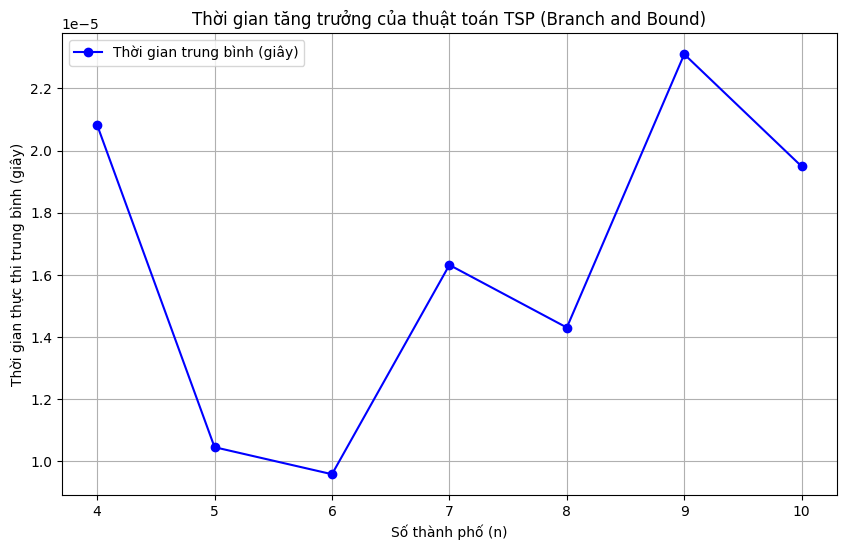

In [ ]:
def generate_random_cost_matrix(n):
    c_matrix = [[0 for _ in range(n + 1)] for _ in range(n + 1)]
    for i in range(1, n + 1):
        for j in range(1, n + 1):
            if i == j:
                c_matrix[i][j] = 0
            else:
                c_matrix[i][j] = random.randint(1, 100)
                c_matrix[j][i] = c_matrix[i][j]  # Đảm bảo ma trận đối xứng
    return c_matrix

# Hàm kiểm tra thời gian thực thi, chạy 20 lần và ghi vào file
def test_time_of_growth():
    n_values = list(range(4, 11))  # Kiểm tra từ n = 4 đến n = 10
    avg_times = []  # Lưu thời gian trung bình cho mỗi n

    # Mở file để ghi kết quả
    with open("tsp_time_results.txt", "w") as f:
        f.write("Kết quả thời gian thực thi thuật toán TSP (Branch and Bound)\n")
        f.write("-------------------------------------------------\n")

        for n in n_values:
            times_for_n = []  # Lưu thời gian của 20 lần chạy cho n hiện tại

            # Chạy 20 lần cho mỗi n
            for run in range(20):
                # Tạo ma trận chi phí ngẫu nhiên
                c_matrix = generate_random_cost_matrix(n)

                # Đo thời gian thực thi
                start_time = time.time()
                branch_and_bound_tsp(n, c_matrix)
                end_time = time.time()

                # Lưu thời gian thực thi (tính bằng giây)
                elapsed_time = end_time - start_time
                times_for_n.append(elapsed_time)

            # Tính thời gian trung bình
            avg_time = sum(times_for_n) / len(times_for_n)
            avg_times.append(avg_time)

            # Ghi kết quả vào file
            f.write(f"n = {n}\n")
            f.write(f"Thời gian từng lần chạy (giây): {', '.join([f'{t:.4f}' for t in times_for_n])}\n")
            f.write(f"Thời gian trung bình: {avg_time:.4f} giây\n")
            f.write("-------------------------------------------------\n")

            print(f"n = {n}, Thời gian trung bình: {avg_time:.4f} giây")

    return n_values, avg_times

# Hàm vẽ biểu đồ thời gian tăng trưởng
def plot_time_of_growth(n_values, avg_times):
    plt.figure(figsize=(10, 6))
    plt.plot(n_values, avg_times, marker='o', linestyle='-', color='b', label='Thời gian trung bình (giây)')
    plt.title('Thời gian tăng trưởng của thuật toán TSP (Branch and Bound)')
    plt.xlabel('Số thành phố (n)')
    plt.ylabel('Thời gian thực thi trung bình (giây)')
    plt.grid(True)
    plt.legend()
    plt.show()

# Chạy thử nghiệm và vẽ biểu đồ
if __name__ == "__main__":
    # Kiểm tra thời gian thực thi
    n_values, avg_times = test_time_of_growth()

    # Vẽ biểu đồ
    plot_time_of_growth(n_values, avg_times)

## **11. Bài toán cái túi:**

In [ ]:
def knapsack_branch_and_bound(n, weight, value, M):
  x = [0] * n # Lưu lựa chọn hiện tại
  best_x = [0] * n # Lựa chọn tốt nhất hiện tại
  sum_best = [0] # Tổng giá trị tốt nhất hiện tại
  weight = [0] # Cân nặng hiện tại
  sum_value = [0] # Tổng giá trị hiện tại

  f = sum(value) # Tính cận trên ban đầu
  def knapsack(i):
    nonlocal f
    for j in  range(2): # j = 0: ko chọn, j = 1: chọn
      x[i] == j
      if j == 1:
        # Nếu chọn món đồ i thì tăng trọng lượng lên j và giá trị lên i
        weight[0] += weight[i]
        sum_value[0] += value[i]
      if i == n - 1 or weight[0] > M: # Nếu đã duyệt hết tất cả các sản phẩm hoặc quá cân nặng
        if weight[0] <= M and sum_value[0] > sum_best[0]: # Kiểm tra bound và lưu lại kết quả
                    sum_best[0] = sum_value[0]
                    best_x[:] = x[:]
        else:
          g = sum_value[0] + (sum(value[i+1:]) * (M - weight[0])) / weight[i+1] if weight[i+1] != 0 else 0
          if g > f:
            knapsack(i + 1)
        if j == 1:
          weight[0] -= weight[i]
          sum_value[0] -= value[i]
  knapsack(0)
  return sum_best[0], best_x

n = 5, Branch and Bound: 0.0000 giây
n = 7, Branch and Bound: 0.0000 giây
n = 9, Branch and Bound: 0.0000 giây
n = 11, Branch and Bound: 0.0000 giây
n = 13, Branch and Bound: 0.0000 giây
n = 15, Branch and Bound: 0.0000 giây
n = 17, Branch and Bound: 0.0000 giây
n = 19, Branch and Bound: 0.0000 giây


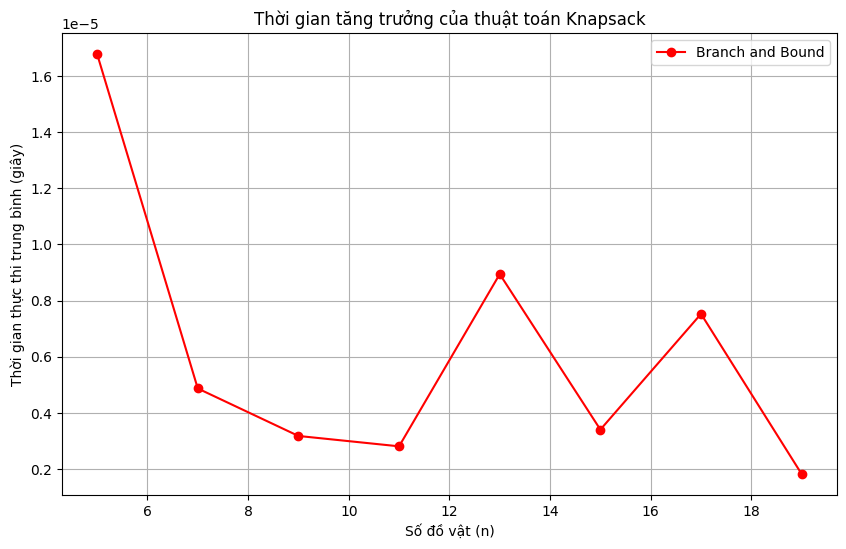

In [ ]:
def generate_random_knapsack_data(n, max_weight, max_value, M):
    weights = [random.randint(1, max_weight) for _ in range(n)]
    values = [random.randint(1, max_value) for _ in range(n)]
    return weights, values, M
def test_time_of_growth():
    n_values = list(range(5, 21, 2))  # Kiểm tra từ n = 5 đến n = 19, bước 2
    avg_times_branch_and_bound = []  # Thời gian trung bình cho Branch and Bound

    # Mở file để ghi kết quả
    with open("knapsack_time_results.txt", "w") as f:
        f.write("Kết quả thời gian thực thi thuật toán Knapsack\n")
        f.write("-------------------------------------------------\n")

        for n in n_values:
            M = n * 10  # Giới hạn trọng lượng M tăng theo n
            times_backtracking = []  # Thời gian của 20 lần chạy cho Backtracking
            times_branch_and_bound = []  # Thời gian của 20 lần chạy cho Branch and Bound

            # Chạy 20 lần cho mỗi n
            for run in range(20):
                # Tạo dữ liệu ngẫu nhiên
                weights, values, M = generate_random_knapsack_data(n, max_weight=20, max_value=50, M=M)



                # Đo thời gian cho Branch and Bound
                start_time = time.time()
                knapsack_branch_and_bound(n, weights, values, M)
                end_time = time.time()
                times_branch_and_bound.append(end_time - start_time)

            # Tính thời gian trung bình
            avg_time_branch_and_bound = sum(times_branch_and_bound) / len(times_branch_and_bound)
            avg_times_branch_and_bound.append(avg_time_branch_and_bound)

            # Ghi kết quả vào file
            f.write(f"n = {n}, M = {M}\n")
            f.write("Phương pháp Branch and Bound:\n")
            f.write(f"Thời gian từng lần chạy (giây): {', '.join([f'{t:.4f}' for t in times_branch_and_bound])}\n")
            f.write(f"Thời gian trung bình: {avg_time_branch_and_bound:.4f} giây\n")
            f.write("-------------------------------------------------\n")

            print(f"n = {n}, Branch and Bound: {avg_time_branch_and_bound:.4f} giây")

    return n_values, avg_times_branch_and_bound

# Hàm vẽ biểu đồ thời gian tăng trưởng
def plot_time_of_growth(n_values, avg_times_branch_and_bound):
    plt.figure(figsize=(10, 6))
    plt.plot(n_values, avg_times_branch_and_bound, marker='o', linestyle='-', color='r', label='Branch and Bound')
    plt.title('Thời gian tăng trưởng của thuật toán Knapsack')
    plt.xlabel('Số đồ vật (n)')
    plt.ylabel('Thời gian thực thi trung bình (giây)')
    plt.grid(True)
    plt.legend()
    plt.show()

# Chạy thử nghiệm và vẽ biểu đồ
if __name__ == "__main__":
    # Kiểm tra thời gian thực thi
    n_values, avg_times_branch_and_bound = test_time_of_growth()

    # Vẽ biểu đồ
    plot_time_of_growth(n_values, avg_times_branch_and_bound)

# Bài 2:

## Bài toán 1: Liệt kê các hoán vị của n phần tử.

### **1. Phân tích bài toán:**
Bài toán yêu cầu liệt kê tất cả các hoán vị của `n` phần tử. Một hoán vị là một
cách sắp xếp các phần tử sao cho mỗi phần tử chỉ xuất hiện đúng một lần và tất cả các phần tử đều được sử dụng. <br>
 - Input: Số nguyên n (số phần tử sẽ được hoán vị) và một tập hợp các phần tử trong đó.
 - Output: Tất cả các cách hoán vị trong tập hợp đó.
 - Ví dụ: Với n = 3 và tập hợp {1, 2, 3} thì các cách hoán vị của nó sẽ là:
 ``` text
1 2 3
1 3 2
2 1 3
2 3 1
3 1 2
3 2 1
 ```

### **1. Phân tích bài toán:**
Bài toán yêu cầu liệt kê tất cả các hoán vị của `n` phần tử. Một hoán vị là một
cách sắp xếp các phần tử sao cho mỗi phần tử chỉ xuất hiện đúng một lần và tất cả các phần tử đều được sử dụng. <br>
 - Input: Số nguyên n (số phần tử sẽ được hoán vị) và một tập hợp các phần tử trong đó.
 - Output: Tất cả các cách hoán vị trong tập hợp đó.
 - Ví dụ: Với n = 3 và tập hợp {1, 2, 3} thì các cách hoán vị của nó sẽ là:
 ``` text
1 2 3
1 3 2
2 1 3
2 3 1
3 1 2
3 2 1
 ```

### **2. Xây dựng thuật toán:**
**Phương pháp 1: Brute Force**
  - Ý tưởng:
    - Sinh tất cả các cách sắp xếp có thể có của n phần tử (bao gồm cả lặp lại).
    - Kiểm tra từng cách sắp xếp để lọc ra các hoán vị hợp lệ (không có phần tử nào lặp lại và sử dụng đúng n phần tử).
  - Các bước:
    1. Sinh tất cả các dãy số có độ dài n từ tập hợp {1, 2, ..., n}.
    2. Với mỗi dãy, kiểm tra xem có phải là hoán vị không (không lặp phần tử).
    3. In ra các dãy thỏa mãn.
  - Ví dụ: Với n = 2, sinh các dãy {1, 1}, {1, 2}, {2, 1}, {2, 2}. Sau khi lọc: {1 2}, {2 1}.

**Phương pháp 2: Backtracking:**
  - Ý tưởng:
    - Xây dựng hoán vị từng bước, sử dụng đệ quy để thử các khả năng.
    - Nếu một phần tử đã được chọn, loại bỏ nó khỏi các lựa chọn tiếp theo (quay lui khi cần).
  - Các bước:
    1. Bắt đầu với một mảng rỗng đại diện cho hoán vị đang xây dựng.
    2. Tại mỗi bước, chọn một phần tử chưa được dùng và thêm vào hoán vị.
    3. Khi độ dài hoán vị đạt n, in kết quả.
    4. Quay lui để thử các khả năng khác.

### **3. Phân tích thuật toán**
**Brute Force:**
  - Độ phức tạp thời gian
    - Sinh tất cả các dãy: O(n^n) (mỗi vị trí có n lựa chọn, tổng cộng n vị trí).
    - Kiểm tra mỗi dãy có phải hoán vị không: O(n) cho mỗi dãy.
    - Tổng: O(n^n × n) = O(n^(n+1)).
  - Ưu điểm: Đơn giản, dễ hiểu
  - Nhược điểm: Không hiệu quả với n lớn vì sinh ra quá nhiều trường hợp không cần thiết.

**Backtracking:**
  - Độ phức tạp thời gian:
    - Số hoán vị của n phần tử là n!.
    - Mỗi hoán vị được sinh ra trong O(n) bước.
    - Tổng: O(n x n!) để sinh và in tất cả hoán vị.
  - Ưu điểm: Hiệu quả hơn Brute Force vì chỉ sinh các hoán vị hợp lệ.
  - Nhược điểm: Cần quản lý trạng thái.

### **4. Chương trình**
**Brute Force**
``` python
def is_permutation(arr, n):
    # Kiểm tra xem mảng có phải là hoán vị không
    used = [False] * (n + 1)
    for num in arr:
        if num < 1 or num > n or used[num]:
            return False
        used[num] = True
    return True

def brute_force_permutations(n):
    def generate_sequences(current, length):
        if len(current) == length:
            if is_permutation(current, n):
                print(" ".join(map(str, current)))
            return
        for i in range(1, n + 1):
            current.append(i)
            generate_sequences(current, length)
            current.pop()

    generate_sequences([], n)
```

**Backtracking**
``` python
def backtracking_permutations(n):
    def permute(current, used):
        if len(current) == n:
            print(" ".join(map(str, current)))
            return
        for i in range(1, n + 1):
            if not used[i]:
                used[i] = True
                current.append(i)
                permute(current, used)
                current.pop()
                used[i] = False

    used = [False] * (n + 1)  # Đánh dấu phần tử đã dùng
    permute([], used)
```
<img title="Time"  src="/content/time_growth.png">


## Bài toán 2: Liệt kê các tổ hợp k phần tử của các số từ 1 đến n.

### **Phân tích bài toán:**
- Định nghĩa: Chọn k phần tử từ n phần tử mà không quan tâm đến thứ tự.
- Công thức: $C(k, n) = \frac{n!}{k!(n-k)!}$
- Ví dụ: n = 2, k = 4
  - Các tổ hợp: {1, 2}, {1, 3}, {1, 4}, {2, 3}, {2, 4}, {3, 4}

### **Phân tích thuật toán:**
1. Brute Force: Sử dụng itertools.combinations
2. Backtracking: Tự sinh tổ hợp bằng cách chọn từng phần tử và quay lui

### **Chương trình**
**Brute Force**
```python
from itertools import combinations

def list_combinations_itertools(n, k):
    numbers = list(range(1, n + 1))  # Tập hợp {1, 2, ..., n}
    combos = list(combinations(numbers, k))  # Sinh tất cả tổ hợp k phần tử
    return combos
```
**Backtracking**
```python
def list_combinations_backtracking(n, k):
    def backtrack(start, curr_combo, result):
        if len(curr_combo) == k:  # Đã chọn đủ k phần tử
            result.append(curr_combo[:])  # Thêm tổ hợp vào kết quả
            return
        
        for i in range(start, n + 1):  # Chọn từ start đến n
            curr_combo.append(i)  # Thêm phần tử vào tổ hợp hiện tại
            backtrack(i + 1, curr_combo, result)  # Tiếp tục với phần tử tiếp theo
            curr_combo.pop()  # Quay lui, bỏ phần tử vừa thêm
    
    result = []
    backtrack(1, [], result)
    return result
```

## Bài toán 3: Bài toán xếp quân cờ

### **1. Phân tích bài toán**
Bài toán yêu cầu xếp 8 quân xe trên bàn cờ vua sao cho không có con nào khống chế được con nào với bàn cờ 8x8. Trong cờ vua, quân xe là quân chỉ có thể đi dọc và đi ngang, do đó 2 quân xe có thể khống chế được nhau khi và chỉ khi 2 quân xe cùng nằm trên một hàng hoặc một cột. Điều này dẫn đến các điều kiện sau:
- Mỗi hàng chỉ chứa tối đa 1 quân xe.
- Mỗi cột chỉ chứa tối đa 1 quân xe.
- Mỗi hàng và mỗi cột phải chứa đúng 1 quân xe.
Đây là một bài toán tổ hợp, tương đương với tìm một hoán vị của 8 số (0 đến 7) đại diện cho các cột, trong đó quân xe ở hàng thứ ⅈ được đặt ở cột 𝒑[ⅈ], với 𝒑[ⅈ] là một hoán vị của {0, 1, 2, 3, 4, 5, 6, 7}. Một cách xếp đơn giản là xếp ở đường chéo chính

### **2. Xây dựng thuật toán**
**1. Brute Force**
- Ý tưởng: Tạo tất cả các hoán vị của {0, 1, 2, 3, 4, 5, 6, 7}, mỗi hoán vị đại diện cho vị trí cột của quân xe trên từng hàng (hàng ⅈ đặt trên quân xe ở cột 𝒑[ⅈ])
- Bước thực hiện:
  1. Sinh tất cả các hoán vị của 8 số (tổng cộng 8! = 40320 hoán vị).
  2. Với mỗi hoán vị, kiểm tra xem có thỏa mãn điều kiện không (thực ra tất cả đều thỏa mãn vì mỗi số chỉ xuất hiện đúng một lần).
  3. Chọn một hoán vị bất kỳ làm kết quả (ví dụ, hoán vị đầu tiên).

**Backtracking**
- Ý tưởng: Đặt từng quân xe vào các cột trên mỗi hàng, kiểm tra ràng buộc, nếu vi phạm thì quay lui để thử vị trí khác.
- Bước thực hiện:
  1. Bắt đầu từ hàng 0, chọn một cột chưa sử dụng để đặt quân xe.
  2. Chuyển sang hàng tiếp theo, lặp lại quá trình, đảm bảo không cột nào bị trùng.
  3. Nếu không thể đặt quân xe ở hàng hiện tại (tất cả cột đã dùng), quay lui về hàng trước và thử cột khác.
  4. Lặp lại cho đến khi đặt đủ 8 quân xe.

### **3. Phân tích thuật toán**
**1. Brute Force**
- Độ phức tạp thời gian: O(n!) với n = 8

**2. Backtracking**
- Độ phức tạp thời gian: Trong trường hợp xấu nhất là O(n!)

### **4. Chương trình**
**Brute Force**
```python
import itertools

def brute_force_rook_placement():
    # Sinh tất cả hoán vị của [0, 1, 2, 3, 4, 5, 6, 7]
    columns = list(range(8))
    permutations = list(itertools.permutations(columns))
    
    # Lấy hoán vị đầu tiên làm ví dụ
    solution = permutations[0]
    board = [['.' for _ in range(8)] for _ in range(8)]
    for row, col in enumerate(solution):
        board[row][col] = 'R'
    
    # In kết quả
    for row in board:
        print(' '.join(row))
    print(f"Tổng số hoán vị: {len(permutations)}")
```

**Backtracking**
``` python
def print_board(board):
    for row in board:
        print(' '.join(row))

def is_safe(used_columns, col):
    return col not in used_columns

def backtracking_rook_placement(board, row, used_columns):
    if row == 8:  # Đã đặt đủ 8 quân xe
        return True
    
    for col in range(8):
        if is_safe(used_columns, col):
            board[row][col] = 'R'
            used_columns.add(col)
            
            if backtracking_rook_placement(board, row + 1, used_columns):
                return True
            
            # Quay lui: bỏ quân xe và thử cột khác
            board[row][col] = '.'
            used_columns.remove(col)
    
    return False
```


Kích thước n = 4
Brute Force: 0.000035 giây
Kết quả Brute Force:
R . . .
. R . .
. . R .
. . . R
Backtracking: 0.000015 giây
Kết quả Backtracking:
R . . .
. R . .
. . R .
. . . R

Kích thước n = 6
Brute Force: 0.000148 giây
Kết quả Brute Force:
R . . . . .
. R . . . .
. . R . . .
. . . R . .
. . . . R .
. . . . . R
Backtracking: 0.000010 giây
Kết quả Backtracking:
R . . . . .
. R . . . .
. . R . . .
. . . R . .
. . . . R .
. . . . . R

Kích thước n = 8
Brute Force: 0.011740 giây
Kết quả Brute Force:
R . . . . . . .
. R . . . . . .
. . R . . . . .
. . . R . . . .
. . . . R . . .
. . . . . R . .
. . . . . . R .
. . . . . . . R
Backtracking: 0.000038 giây
Kết quả Backtracking:
R . . . . . . .
. R . . . . . .
. . R . . . . .
. . . R . . . .
. . . . R . . .
. . . . . R . .
. . . . . . R .
. . . . . . . R


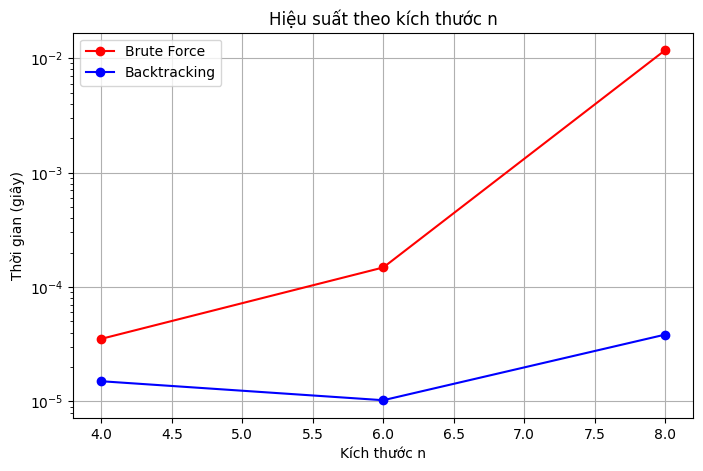

In [10]:
import time
import itertools
import matplotlib.pyplot as plt

def print_board(board):
    for row in board:
        print(' '.join(row))

# 1. Brute Force
def brute_force_rook_placement(n):
    columns = list(range(n))
    permutations = list(itertools.permutations(columns))
    solution = permutations[0]
    board = [['.' for _ in range(n)] for _ in range(n)]
    for row, col in enumerate(solution):
        board[row][col] = 'R'
    return board

# 2. Backtracking
def is_safe(used_columns, col):
    return col not in used_columns

def backtracking_rook_placement(board, row, used_columns, n):
    if row == n:
        return True
    for col in range(n):
        if is_safe(used_columns, col):
            board[row][col] = 'R'
            used_columns.add(col)
            if backtracking_rook_placement(board, row + 1, used_columns, n):
                return True
            board[row][col] = '.'
            used_columns.remove(col)
    return False

def solve_backtracking(n):
    board = [['.' for _ in range(n)] for _ in range(n)]
    used_columns = set()
    backtracking_rook_placement(board, 0, used_columns, n)
    return board


def measure_time(algorithm, n):
    start_time = time.time()
    if algorithm == "brute_force":
        brute_force_rook_placement(n)
    else:  # backtracking
        solve_backtracking(n)
    end_time = time.time()
    return end_time - start_time

n_values = [4, 6, 8]
brute_force_times = []
backtracking_times = []

for n in n_values:
    print(f"\nKích thước n = {n}")

    # Đo Brute Force
    bf_time = measure_time("brute_force", n)
    brute_force_times.append(bf_time)
    print(f"Brute Force: {bf_time:.6f} giây")
    board_bf = brute_force_rook_placement(n)
    print("Kết quả Brute Force:")
    print_board(board_bf)

    # Đo Backtracking
    bt_time = measure_time("backtracking", n)
    backtracking_times.append(bt_time)
    print(f"Backtracking: {bt_time:.6f} giây")
    board_bt = solve_backtracking(n)
    print("Kết quả Backtracking:")
    print_board(board_bt)

plt.figure(figsize=(8, 5))
plt.plot(n_values, brute_force_times, label='Brute Force', marker='o', color='red')
plt.plot(n_values, backtracking_times, label='Backtracking', marker='o', color='blue')
plt.title('Hiệu suất theo kích thước n')
plt.xlabel('Kích thước n')
plt.ylabel('Thời gian (giây)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

## Bài toán 4: Map coloring Problem

### **Phân tích bài toán:**
- Định nghĩa:
  - Cho một bản đồ (được biểu diễn dưới dạng đồ thị), trong đó các vùng (vertices) được nối với nhau bởi các biên giới (edges).
  - Mục tiêu: Tô màu các vùng sao cho không có hai vùng kề nhau (có cùng biên giới) mang cùng màu.
  - Số màu tối thiểu cần dùng gọi là số màu sắc của đồ thị.
- Ví dụ:
  - Bản đồ 4 vùng (A, B, C, D) với các biên giới:
    - A kề B, A kề C, B kề D, C kề D
  - Cần tô màu sao cho A khác B, A khác C, B khác D, C khác D.
- Ràng buộc:
  - Số màu được dùng thường là cố định.
  - Mỗi đỉnh chỉ được gán 1 màu.


### **Phân tích thuật toán:**
**1. Backtracking:**
- Ý tưởng:
  - Chọn một đỉnh (vùng) chưa được tô màu.
  - Thử gán từng màu cho đỉnh đó, kiểm tra xem có hợp lệ không (không trùng với đỉnh kề) không.
  - Nếu hợp lệ, chuyển sang đỉnh tiếp theo, nếu không quay lui và thử màu khác.
  - Lặp lại đến khi tô màu hết tất cả các đỉnh hoặc kết luận không khả thi.
- Độ phức tạp thời gian: $O(m^V)$, trong đó:
  - m: số màu
  - V: số đỉnh
  - Worst case: thử tất cả các màu cho mỗi đỉnh

**2. Branch and bound**
- Ý tường: Tương tự Backtracking nhưng tìm số màu tối thiểu (chromatic number) và cắt tỉa các nhánh không hứa hẹn bằng cách thử từ số màu nhỏ nhất, loại bỏ sớm các trường hợp không khả thi.
- Cách hoạt động:
  1. Bắt đầu với số màu m = 1
  2. Tô màu từng đỉnh, kiểm tra tính khả thi
  3. Nếu không thể tô hết với m màu, tăng m lên và thử lại.
  4. Nếu một đỉnh cần màu lớn hơn m hiện tại, bỏ nhánh đó.

### **Chương trình:**
**Backtracking:**
```python
# Backtracking
def is_safe(graph, vertex, color, colors_assigned, num_vertices):
  # graph: ma trận kề đang sử dụng
  # vertex: đỉnh đang xét
  # color: màu đang thử gán
  # colors_assigned: Mảng lưu màu đã gán cho các đỉnh (-1 là chưa gán)
  # num_vertices: số đỉnh trong đồ thị
  for i in range(num_vertices):
    # Duyệt qua các đỉnh để kiểm tra đỉnh kề
    if graph[vertex][i] == 1 and colors_assigned[i] == color:
      # nếu có đỉnh kề và đỉnh kề đó đang được gán màu color
      return False
  return True

def graph_color_backtracking(graph, num_colors, colors_assigned, vertex, num_vertices):
  # Nếu đã tô hết  thì thành công
  if vertex == num_vertices:
    return True
  # Thử từng màu cho đỉnh hiện tại
  for color in range(num_colors):
    # Nếu màu 'color' có thể gán cho vertex
    if is_safe(graph, vertex, color, colors_assigned, num_vertices):
      colors_assigned[vertex] = color # Gán màu cho đỉnh
      if graph_color_backtracking(graph, num_colors, colors_assigned, vertex + 1, num_vertices):
        return True
        # Nếu không thành công, quay lui bằng cách bỏ màu
        colors_assigned[vertex] = -1
    return False
def solve_backtracking(graph, num_colors):
  num_vertices = len(graph)
  color_assigned = [-1] * num_vertices
  # Bắt đầu từ đỉnh 0
  if graph_color_backtracking(graph, num_colors, color_assigned, 0, num_vertices):
    return color_assigned
  return None
```

**Branch and bound**
```python
# Branch and bound
def graph_coloring_branch_and_bound(graph, max_colors):
  num_vertices = len(graph)
  colors_assigned = [-1] * num_vertices
  current_max_color = 0
  def bnb_util(vertex, num_vertices):
    nonlocal current_max_color
    # Nếu đã tô hết tất cả đỉnh, thành công
    if vertex == num_vertices:
      return True
    
    # Thử tất cả các màu từ 0 đến current_max_color + 1
    for color in range(current_max_color + 1):
      # Nếu màu 'color' an toàn cho 'vertex'
      if is_safe(graph, vertex, color, colors_assigned, num_vertices):
        colors_assigned[vertex] = color
        if bnb_util(vertex + 1, num_vertices):
          return True
        colors_assigned[vertex] = -1

    # Nếu không màu nào trong current_max_color khả thi, tăng số màu (nếu chưa vượt quá max_colors)
    if current_max_color + 1 < max_colors:
      current_max_color += 1
      colors_assigned[vertex] = current_max_color
      if bnb_util(vertex + 1, num_vertices):
        return True
        
      colors_assigned[vertex] = -1
    return False
  if bnb_util(0, num_vertices):
    return colors_assigned, current_max_color + 1 # Trả về kết quả và số màu
  return None, None
```

In [16]:
# Backtracking
def is_safe(graph, vertex, color, colors_assigned, num_vertices):
  # graph: ma trận kề đang sử dụng
  # vertex: đỉnh đang xét
  # color: màu đang thử gán
  # colors_assigned: Mảng lưu màu đã gán cho các đỉnh (-1 là chưa gán)
  # num_vertices: số đỉnh trong đồ thị
  for i in range(num_vertices):
    # Duyệt qua các đỉnh để kiểm tra đỉnh kề
    if graph[vertex][i] == 1 and colors_assigned[i] == color:
      # nếu có đỉnh kề và đỉnh kề đó đang được gán màu color
      return False
  return True

def graph_color_backtracking(graph, num_colors, colors_assigned, vertex, num_vertices):
  # Nếu đã tô hết  thì thành công
  if vertex == num_vertices:
    return True
  # Thử từng màu cho đỉnh hiện tại
  for color in range(num_colors):
    # Nếu màu 'color' có thể gán cho vertex
    if is_safe(graph, vertex, color, colors_assigned, num_vertices):
      colors_assigned[vertex] = color # Gán màu cho đỉnh
      if graph_color_backtracking(graph, num_colors, colors_assigned, vertex + 1, num_vertices):
        return True
        # Nếu không thành công, quay lui bằng cách bỏ màu
        colors_assigned[vertex] = -1
  return False
def solve_backtracking(graph, num_colors):
  num_vertices = len(graph)
  color_assigned = [-1] * num_vertices
  # Bắt đầu từ đỉnh 0
  if graph_color_backtracking(graph, num_colors, color_assigned, 0, num_vertices):
    return color_assigned
  return None

In [22]:
# Branch and bound
def graph_coloring_branch_and_bound(graph, max_colors):
  num_vertices = len(graph)
  colors_assigned = [-1] * num_vertices
  current_max_color = 0
  def bnb_util(vertex, num_vertices):
    nonlocal current_max_color
    # Nếu đã tô hết tất cả đỉnh, thành công
    if vertex == num_vertices:
      return True

    # Thử tất cả các màu từ 0 đến current_max_color + 1
    for color in range(current_max_color + 1):
      # Nếu màu 'color' an toàn cho 'vertex'
      if is_safe(graph, vertex, color, colors_assigned, num_vertices):
        colors_assigned[vertex] = color
        if bnb_util(vertex + 1, num_vertices):
          return True
        colors_assigned[vertex] = -1

    # Nếu không màu nào trong current_max_color khả thi, tăng số màu (nếu chưa vượt quá max_colors)
    if current_max_color + 1 < max_colors:
      current_max_color += 1
      colors_assigned[vertex] = current_max_color
      if bnb_util(vertex + 1, num_vertices):
        return True

      colors_assigned[vertex] = -1
    return False
  if bnb_util(0, num_vertices):
    return colors_assigned, current_max_color + 1 # Trả về kết quả và số màu
  return None, None


In [23]:
graph = [
    [0, 1, 1, 0],  # A kề B, C
    [1, 0, 0, 1],  # B kề A, D
    [1, 0, 0, 1],  # C kề A, D
    [0, 1, 1, 0]   # D kề B, C
]
vertices = ['A', 'B', 'C', 'D']  # Danh sách tên vùng
num_vertices = len(graph)
num_colors = 3
print("Backtracking với 3 màu:")
result_bt = solve_backtracking(graph, num_colors)
if result_bt:
    for vertex, color in enumerate(result_bt):
        print(f"Vùng {vertices[vertex]}: Màu {color}")
else:
    print("Không thể tô màu.")

max_colors = 4
print("\nBranch and Bound:")
result_bnb, min_colors = graph_coloring_branch_and_bound(graph, max_colors)
if result_bnb:
    for vertex, color in enumerate(result_bnb):
        print(f"Vùng {vertices[vertex]}: Màu {color}")
    print(f"Số màu tối thiểu: {min_colors}")
else:
    print(f"Không thể tô màu với {max_colors} màu.")

Backtracking với 3 màu:
Vùng A: Màu 0
Vùng B: Màu 1
Vùng C: Màu 1
Vùng D: Màu 0

Branch and Bound:
Vùng A: Màu 0
Vùng B: Màu 1
Vùng C: Màu 1
Vùng D: Màu 0
Số màu tối thiểu: 2
